<a href="https://colab.research.google.com/github/Mozoonn/arti560-computer-vision-labs/blob/main/lab03-image-classification-vision-transformer-vit/lab03-image-classification-vision-transformer-vit-exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras-hub


Predictions:

True label: dog (index:207), Predicted Index: 207 --> correct prediction


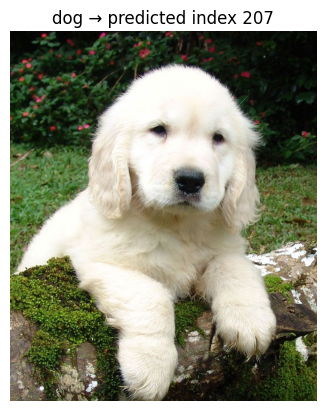

True label: cat (index:281), Predicted Index: 282 --> incorrect prediction


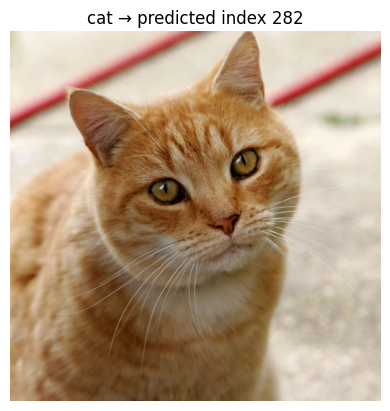

True label: airplane (index:404), Predicted Index: 404 --> correct prediction


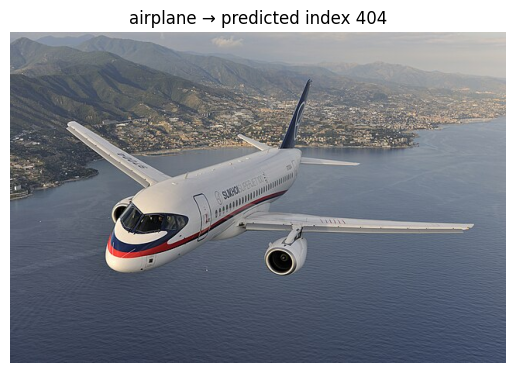

True label: bus (index:779), Predicted Index: 705 --> incorrect prediction


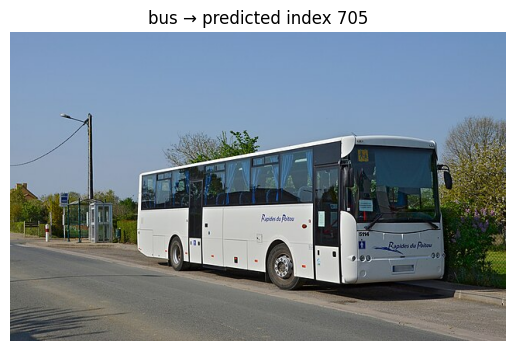

True label: bird (index:16), Predicted Index: 11 --> incorrect prediction


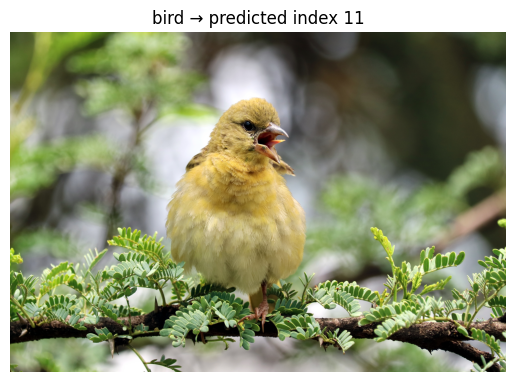

In [ ]:
import tensorflow as tf
import keras_hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load preprocessor
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

# Load model WITH preprocessor attached
classifier = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    preprocessor=preprocessor
)

images = {
    "dog": "/Golde33443.jpg",
    "cat": "/Cat03.jpg",
    "airplane": "/airplane.jpg",
    "bus": "/bus.jpg",
    "bird": "/bird.jpg"
}

# ImageNet index mapping
mapping = {
    "dog": 207,
    "cat": 281,
    "airplane": 404,
    "bus": 779,
    "bird": 16
}

print("\nPredictions:\n")

for name, path in images.items():

    image = Image.open(path).convert("RGB")
    img_array = np.array(image)

    # Predict (preprocessing handled automatically)
    pred_probs = classifier.predict([img_array], verbose=0)
    top5 = np.argsort(pred_probs[0])[-5:][::-1]
    pred_index = top5[0]

    if name in mapping:

        if pred_index == mapping[name]:
            print(f"True label: {name} (index:{mapping[name]}), Predicted Index: {pred_index} --> correct prediction")

        else:
            print(f"True label: {name} (index:{mapping[name]}), Predicted Index: {pred_index} --> incorrect prediction")

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{name} → predicted index {pred_index}")
    plt.show()

| Image File   | Predicted Label    | True Label | Correct? |
| ------------ | ---------------------------- | ------------------------------ | -------- |
| dog.jpg      | golden retriever (207)       | dog                            | Yes      |
| cat.jpg      | tiger cat (282)              | cat                            | Yes      |
| airplane.jpg | airliner (404)               | airplane                       | Yes      |
| bus.jpg      | passenger car (705)          | bus                            | No       |
| bird.jpg     | brambling / finch class (11) | bird                           | No       |
